# 06f - Decision Tree Explanation
Vizualizace rozhodovacího stromu a vysvetleni klasifikace vybrane instance.

**Bod zadani 2:** Vysvetlete, jak model rozhodovacího stromu dospel ke svemu zaveru.
**Bod zadani 3+4+5:** Klasifikace vybrane instance vsemi modely, shoda, spolehlivost.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

ctx           = joblib.load('../results/xai/xai_context.pkl')
X_train_prep  = ctx['X_train_prep']
X_test_prep   = ctx['X_test_prep']
y_test        = ctx['y_test']
tuned_models  = ctx['tuned_models']
student_index = ctx['student_index']
risky_student = ctx['risky_student']
student_prob  = ctx['student_prob']
winning_name  = ctx['winning_name']

# Decision Tree — tuned verze z 03d (konzistentni s ostatnimi modely v pipeline)
# Tuned modely jsou ImbPipeline; extrahujeme samotny estimator
_dt_pipeline = joblib.load('../models/tuned/decision_tree_tuned.pkl')
if hasattr(_dt_pipeline, 'named_steps') and 'model' in _dt_pipeline.named_steps:
    dt_model = _dt_pipeline.named_steps['model']
else:
    dt_model = _dt_pipeline

print(f"Vybrana instance: student index {student_index}, riziko {student_prob:.1%}")
print(f"Skutecna trida: {y_test.iloc[student_index]} (1=Dropout, 0=Dostuduje)")
print(f"Decision Tree: max_depth={dt_model.max_depth}, class_weight={dt_model.class_weight}")
print(f"Feature names ({len(X_test_prep.columns)}): {list(X_test_prep.columns)}")

import matplotlib as _mpl

# Paul Tol bright palette — colorblind-safe, perceptually uniform
_PALETTE = ['#0077BB', '#EE7733', '#009988', '#CC3311', '#33BBEE', '#EE3377', '#BBBBBB']

_mpl.rcParams.update({
    # Color cycle
    'axes.prop_cycle':       _mpl.cycler(color=_PALETTE),

    # Backgrounds
    'figure.facecolor':      'white',
    'axes.facecolor':        '#F8F9FA',   # subtle off-white — "card" feel

    # Spines
    'axes.edgecolor':        '#DEE2E6',
    'axes.linewidth':        0.9,
    'axes.spines.top':       False,
    'axes.spines.right':     False,

    # Grid — solid, very light
    'axes.grid':             True,
    'axes.axisbelow':        True,
    'grid.color':            '#E9ECEF',
    'grid.linestyle':        '-',
    'grid.linewidth':        0.8,
    'grid.alpha':            1.0,

    # Typography
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'axes.titlesize':        14,
    'axes.titleweight':      'bold',
    'axes.titlepad':         14,
    'axes.labelsize':        12,
    'axes.labelweight':      'regular',
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':       10,
    'legend.title_fontsize': 11,
    'figure.titlesize':      16,
    'figure.titleweight':    'bold',

    # Text colors — near-black for contrast
    'text.color':            '#212529',
    'axes.labelcolor':       '#495057',
    'xtick.color':           '#495057',
    'ytick.color':           '#495057',

    # Ticks
    'xtick.direction':       'out',
    'ytick.direction':       'out',
    'xtick.major.size':      4,
    'ytick.major.size':      4,
    'xtick.minor.visible':   False,
    'ytick.minor.visible':   False,
    'xtick.major.pad':       5,
    'ytick.major.pad':       5,

    # Lines & markers
    'lines.linewidth':       2.0,
    'lines.markersize':      7,
    'patch.linewidth':       0.6,

    # Legend
    'legend.frameon':        True,
    'legend.framealpha':     0.92,
    'legend.edgecolor':      '#DEE2E6',
    'legend.fancybox':       True,
    'legend.borderpad':      0.6,

    # Figure / saving
    'figure.dpi':            100,
    'figure.figsize':        [8, 5],
    'savefig.dpi':           150,
    'savefig.bbox':          'tight',
    'savefig.facecolor':     'white',
    'savefig.edgecolor':     'none',
})


Vybrana instance: student index 16, riziko 80.8%
Skutecna trida: 0 (1=Dropout, 0=Dostuduje)
Decision Tree: max_depth=5, class_weight=balanced
Feature names (19): ['Family_Income', 'Study_Hours_per_Day', 'Stress_Index', 'Age_Gap', 'CGPA', 'GPA_trend', 'Department_Arts', 'Department_Business', 'Department_CS', 'Department_Engineering', 'Department_Science', 'Gender', 'Internet_Access', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Semester']


## Vizualizace rozhodovacího stromu (max_depth=3)
Zobrazujeme prvni 3 urovne stromu — hlubsi uzly jsou prilis detailni pro vizualizaci.

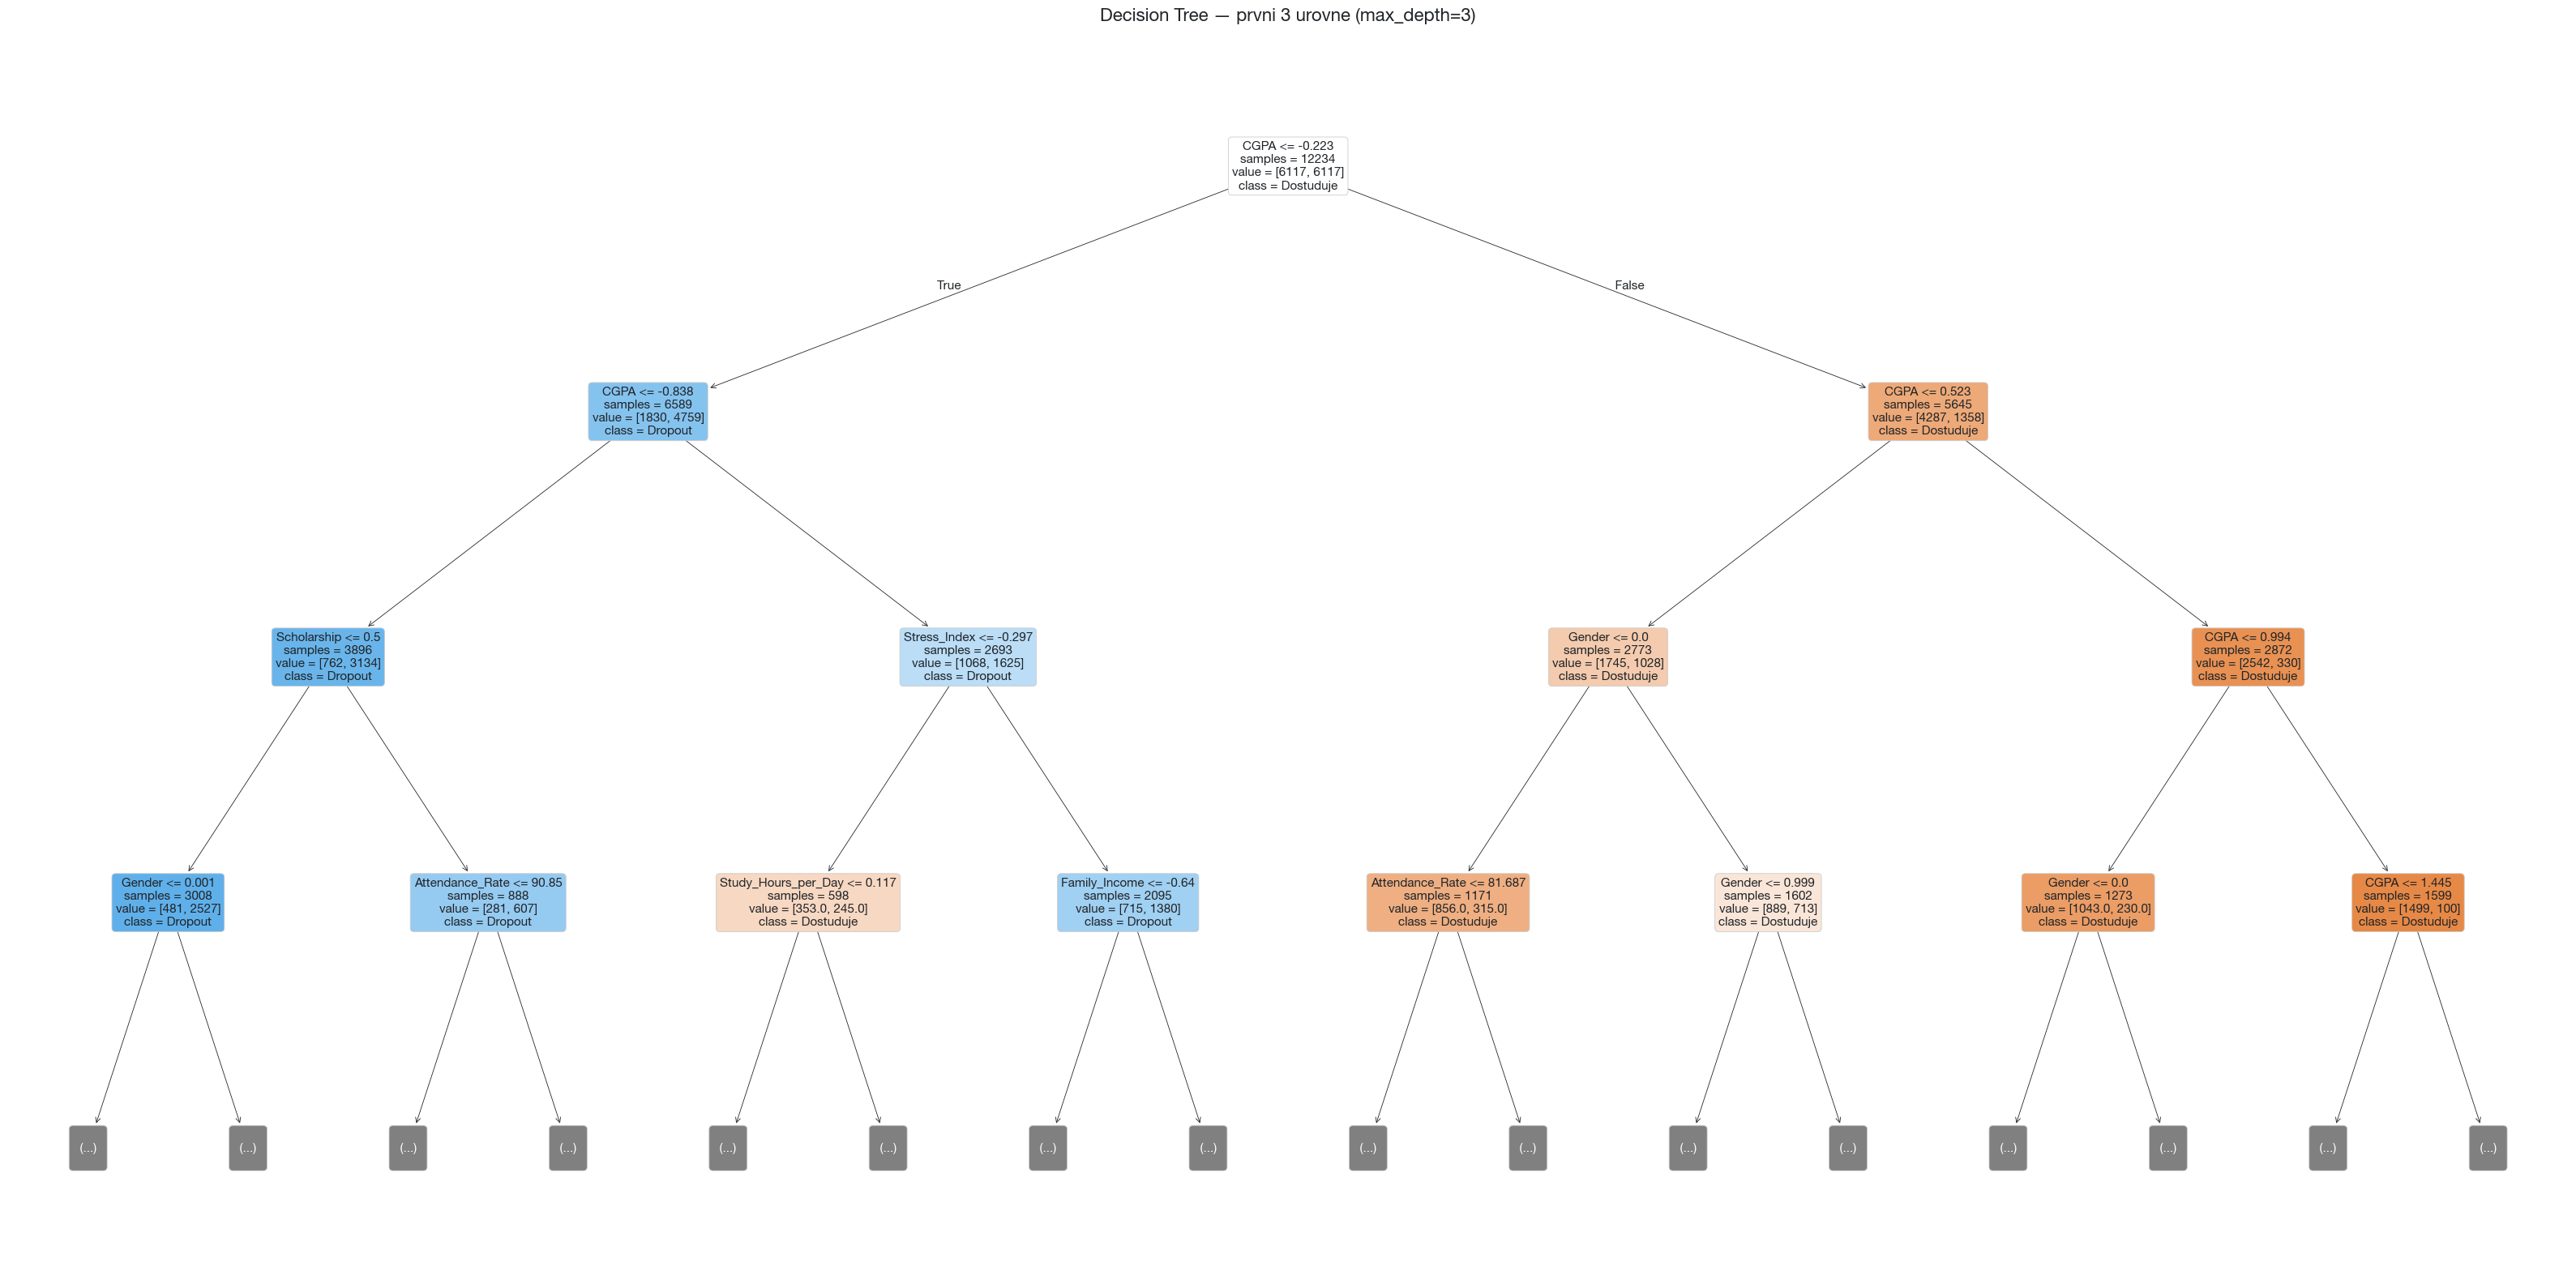

Strom ulozen: results/decision_tree_viz.png


In [2]:
# ── Vizualizace stromu — prvni 3 urovne ─────────────────────────────────────
# figsize=(32,16): dostatek mista pro 19 priznaku; fontsize=11 pro citelnost
fig, ax = plt.subplots(figsize=(32, 16), facecolor='white')
ax.set_facecolor('white')

plot_tree(
    dt_model,
    feature_names=X_test_prep.columns.tolist(),
    class_names=['Dostuduje', 'Dropout'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=11,
    ax=ax,
    impurity=False,
    proportion=False,
    precision=3,
)

# Post-processing: auto-kontrast textu (svetle pozadi -> tmavy text, tmave -> bily)
for artist in ax.get_children():
    import matplotlib.text as _mtext
    if isinstance(artist, _mtext.Annotation):
        bp = artist.get_bbox_patch()
        if bp is not None:
            fc = bp.get_facecolor()          # (r, g, b, a)
            r, g, b = fc[0], fc[1], fc[2]
            # Relativni jasovost (ITU-R BT.601)
            lum = 0.299 * r + 0.587 * g + 0.114 * b
            artist.set_color('white' if lum < 0.55 else '#212529')
            bp.set_edgecolor('#CCCCCC')
            bp.set_linewidth(0.6)

ax.set_title('Decision Tree — prvni 3 urovne (max_depth=3)',
             fontsize=16, fontweight='bold', pad=20, color='#212529')
fig.patch.set_facecolor('white')
plt.tight_layout(pad=1.5)

import os as _os
_os.makedirs('../results', exist_ok=True)
plt.savefig('../results/decision_tree_viz.png', dpi=120, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Strom ulozen: results/decision_tree_viz.png")


## Cesta rozhodovacím stromem pro vybranou instanci
Sledujeme ktery uzel byl aktivovan pri klasifikaci studenta c. {student_index}.

In [3]:
from sklearn.tree import _tree

def get_decision_path(model, instance, feature_names):
    tree_       = model.tree_
    feature     = tree_.feature
    threshold   = tree_.threshold
    node_ind = model.decision_path(instance.to_frame().T).indices

    path_steps = []
    for i, node in enumerate(node_ind):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            # Listy
            class_idx  = tree_.value[node].argmax()
            class_name = ['Dostuduje', 'Dropout'][class_idx]
            proba      = tree_.value[node][0, class_idx] / tree_.value[node].sum()
            path_steps.append(f"  LEAF → Predikce: {class_name} ({proba:.1%})")
        else:
            feat_name = feature_names[feature[node]]
            val       = float(instance.iloc[feature[node]])
            thr       = threshold[node]
            direction = '<= ' if val <= thr else '> '
            path_steps.append(
                f"  Uzel {node}: {feat_name} = {val:.3f}  {direction}{thr:.3f}"
            )
    return path_steps

feature_names = X_test_prep.columns.tolist()
# 1. Zeptáme se modelu, na jakých 17 sloupcích se učil (tohle on si pamatuje)
expected_features = dt_model.feature_names_in_

# 2. Ořízneme našeho studenta z 19 sloupců jen na těch 17 správných
risky_student_filtered = risky_student[expected_features]

path = get_decision_path(dt_model, risky_student_filtered, expected_features)

print(f"Rozhodovaci cesta pro studenta c. {student_index} (riziko {student_prob:.1%}):")
print(f"{'=' * 60}")
for step in path:
    print(step)

# Tady si z toho uděláme hezkou tabulku s jedním řádkem
student_df = risky_student_filtered.to_frame().T

# A rovnou ji pošleme do modelu (bez reshape)
dt_pred  = dt_model.predict(student_df)[0]
dt_proba = dt_model.predict_proba(student_df)[0]
print(f"\nFinalní predikce DT: {'Dropout' if dt_pred == 1 else 'Dostuduje'}")
print(f"Pravdepodobnost Dropout: {dt_proba[1]:.1%}")

Rozhodovaci cesta pro studenta c. 16 (riziko 80.8%):
  Uzel 0: CGPA = -1.779  <= -0.223
  Uzel 1: CGPA = -1.779  <= -0.838
  Uzel 2: Scholarship = 1.000  > 0.500
  Uzel 10: Attendance_Rate = 85.700  <= 90.850
  Uzel 11: Stress_Index = -0.416  <= -0.009
  LEAF → Predikce: Dropout (57.9%)

Finalní predikce DT: Dropout
Pravdepodobnost Dropout: 57.9%


## Textový výpis celého stromu (pravidla)
Kompaktnı textova reprezentace vsech rozhodovacich pravidel.

In [4]:
rules = export_text(dt_model, feature_names=list(dt_model.feature_names_in_), max_depth=4)
print(rules[:5000])  # prvnich 5000 znaku — cely strom muze byt dlouhy

|--- CGPA <= -0.22
|   |--- CGPA <= -0.84
|   |   |--- Scholarship <= 0.50
|   |   |   |--- Gender <= 0.00
|   |   |   |   |--- CGPA <= -1.20
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- CGPA >  -1.20
|   |   |   |   |   |--- class: 1
|   |   |   |--- Gender >  0.00
|   |   |   |   |--- Gender <= 1.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Gender >  1.00
|   |   |   |   |   |--- class: 1
|   |   |--- Scholarship >  0.50
|   |   |   |--- Attendance_Rate <= 90.85
|   |   |   |   |--- Stress_Index <= -0.01
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Stress_Index >  -0.01
|   |   |   |   |   |--- class: 1
|   |   |   |--- Attendance_Rate >  90.85
|   |   |   |   |--- Department_Science <= 0.19
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Department_Science >  0.19
|   |   |   |   |   |--- class: 1
|   |--- CGPA >  -0.84
|   |   |--- Stress_Index <= -0.30
|   |   |   |--- Study_Hours_per_Day <= 0.12
|   |   |   |   |--- Study_Hours_per_Day <= -

## Bod 3+4+5: Klasifikace vybrané instance všemi modely
Porovname predikci vsech modelu pro studenta c. {student_index}.
- Predikuji vsechny modely stejnou tridu?
- Jaka je spolehlivost (pravdepodobnost) predikce?

Vybrana instance: student c. 16
Skutecna trida:   Dostuduje (0)
              Model    Predikce P(Dropout) P(Dostuduje) Shoda s vítězem Spravna predikce
Logistic Regression Dropout (1)      80.8%        19.2%             ANO               NE
      Random Forest Dropout (1)      55.4%        44.6%             ANO               NE
  Gradient Boosting Dropout (1)      59.8%        40.2%             ANO               NE
      Decision Tree Dropout (1)      57.9%        42.1%             ANO               NE


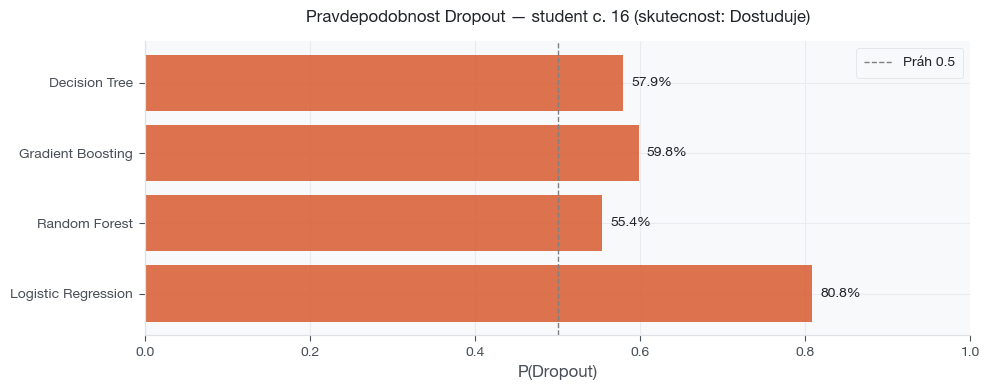


ZAVER: VSECHNY modely predikuji shodne — Dropout (1)


In [5]:
all_models = dict(tuned_models)
all_models['Decision Tree'] = dt_model

rows = []
skutecna_trida = int(y_test.iloc[student_index])

for name, model in all_models.items():
    # 1. Zeptáme se aktuálního modelu v cyklu, jaké sloupce přesně vyžaduje
    if hasattr(model, 'feature_names_in_'):
        expected_cols = model.feature_names_in_
        # Ořízneme studenta přesně pro tento model a uděláme z něj tabulku
        X_input = risky_student[expected_cols].to_frame().T
    else:
        # Fallback (pro jistotu)
        X_input = risky_student.to_frame().T

    # 2. Samotná predikce (už používá oříznutá čistá data X_input)
    pred  = int(model.predict(X_input)[0])
    proba = model.predict_proba(X_input)[0]

    rows.append({
        'Model':              name,
        'Predikce':           'Dropout (1)' if pred == 1 else 'Dostuduje (0)',
        'P(Dropout)':         f"{proba[1]:.1%}",
        'P(Dostuduje)':       f"{proba[0]:.1%}",
        'Shoda s vítězem':    'ANO' if pred == 1 else 'NE',
        'Spravna predikce':   'ANO' if pred == skutecna_trida else 'NE',
    })

df_compare = pd.DataFrame(rows)
print(f"Vybrana instance: student c. {student_index}")
print(f"Skutecna trida:   {'Dropout (1)' if skutecna_trida == 1 else 'Dostuduje (0)'}")
print(f"{'=' * 75}")
print(df_compare.to_string(index=False))

# Vizualizace pravdepodobnosti
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#D85A30' if '1' in r['Predikce'] else '#178ADD' for _, r in df_compare.iterrows()]
proba_vals = [float(r['P(Dropout)'].rstrip('%')) / 100 for _, r in df_compare.iterrows()]
bars = ax.barh(df_compare['Model'], proba_vals, color=colors, alpha=0.85)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Práh 0.5')
ax.set_xlabel('P(Dropout)')
ax.set_title(f'Pravdepodobnost Dropout — student c. {student_index} (skutecnost: {"Dropout" if skutecna_trida else "Dostuduje"})', fontsize=12)
ax.set_xlim(0, 1)
for bar, val in zip(bars, proba_vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

# Explicitní odpověď: shodují se modely?
predikce_int = [1 if '1' in r['Predikce'] else 0 for r in rows]
if len(set(predikce_int)) == 1:
    print(f"\nZAVER: VSECHNY modely predikuji shodne — {'Dropout (1)' if predikce_int[0] == 1 else 'Dostuduje (0)'}")
else:
    print(f"\nZAVER: Modely se NESHODUJI — rozlicne predikce pro studenta c. {student_index}")
    for r in rows:
        print(f"  {r['Model']}: {r['Predikce']}")